# Ingeniería de Características Espaciales

En clases anteriores partimos de datos ya listos para el análisis. En la práctica, los datos casi nunca vienen con todas las variables que necesitamos: hay que **construirlas**. Ese proceso se llama ingeniería de características (*feature engineering*), y cuando los datos son espaciales, la geografía se convierte en la herramienta de construcción principal.

La intuición es simple: **la proximidad en el espacio suele implicar relaciones sustantivas**. Si quiero saber si un Airbnb es caro porque está bien ubicado, necesito medir qué tan bien ubicado está y para eso necesito información del entorno.

Seguimos con los **Airbnbs de San Diego** del capítulo de regresión (clases 08 y 09). Al final nos preguntamos: ¿las características espaciales que construyamos mejoran la predicción del precio respecto al OLS, SAR y SEM que ya teníamos?

## Lo que veremos

**Parte 1: Map Matching**: conectar datasets distintos usando el espacio como llave:
1. Contar puntos de interés cercanos (buffer + `sjoin`).
2. Extraer elevación de un raster (DEM).
3. Heredar atributos de polígonos (punto en polígono).

**Parte 2: ¿Mejora la regresión?**
4. Comparar OLS, SAR y SEM antes y después de agregar las features de map matching.

Adaptado de Rey, Arribas-Bel & Wolf (2023), *Geographic Data Science with Python*, Capítulo 12.

## 1. Preparación: librerías y datos

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import rasterstats
import rioxarray

from libpysal import weights
from sklearn.cluster import HDBSCAN
from pysal.model import spreg

%config InlineBackend.figure_format = "retina"
np.random.seed(42)

sns.set(style="ticks", font="sans-serif", context="notebook", palette="viridis")
plt.rcParams["figure.dpi"] = 96
plt.rcParams["font.family"] = "Fira Sans Extra Condensed"

pd.set_option("display.max_columns", None)

# CRS de trabajo: California Albers (metros) para todos los cálculos de distancia
CRS  = "EPSG:3311"
RUTA = "datos/external"

Cargamos los tres datasets de San Diego que usaremos en esta clase.

In [2]:
db     = gpd.read_file(f"{RUTA}/airbnb_sd/regression_db.geojson").to_crs(CRS)
tracts = gpd.read_file(f"{RUTA}/sandiego/sandiego_tracts.gpkg").to_crs(CRS)
pois   = gpd.read_file(f"{RUTA}/sandiego/pois_sd.gpkg").to_crs(CRS)

print(f"Airbnbs : {len(db):,}  propiedades")
print(f"Tracts  : {len(tracts):,}  census tracts")
print(f"POIs    : {len(pois):,}  restaurantes, bares y cafés (OpenStreetMap)")

Airbnbs : 6,110  propiedades
Tracts  : 628  census tracts
POIs    : 1,920  restaurantes, bares y cafés (OpenStreetMap)


In [3]:
pois.head()

,amenity,name,geometry
0,restaurant,Leucadia Pizzeria & Italian Restaurant,POINT (260043.826 -568463.827)
1,restaurant,Egglet,POINT (260049.490 -568502.600)
2,restaurant,Thai Time 3,POINT (264018.841 -572886.887)
3,cafe,Tapioca Express,POINT (260048.078 -568418.192)
4,restaurant,Sipz Fusion Cafe,POINT (264907.898 -571502.591)


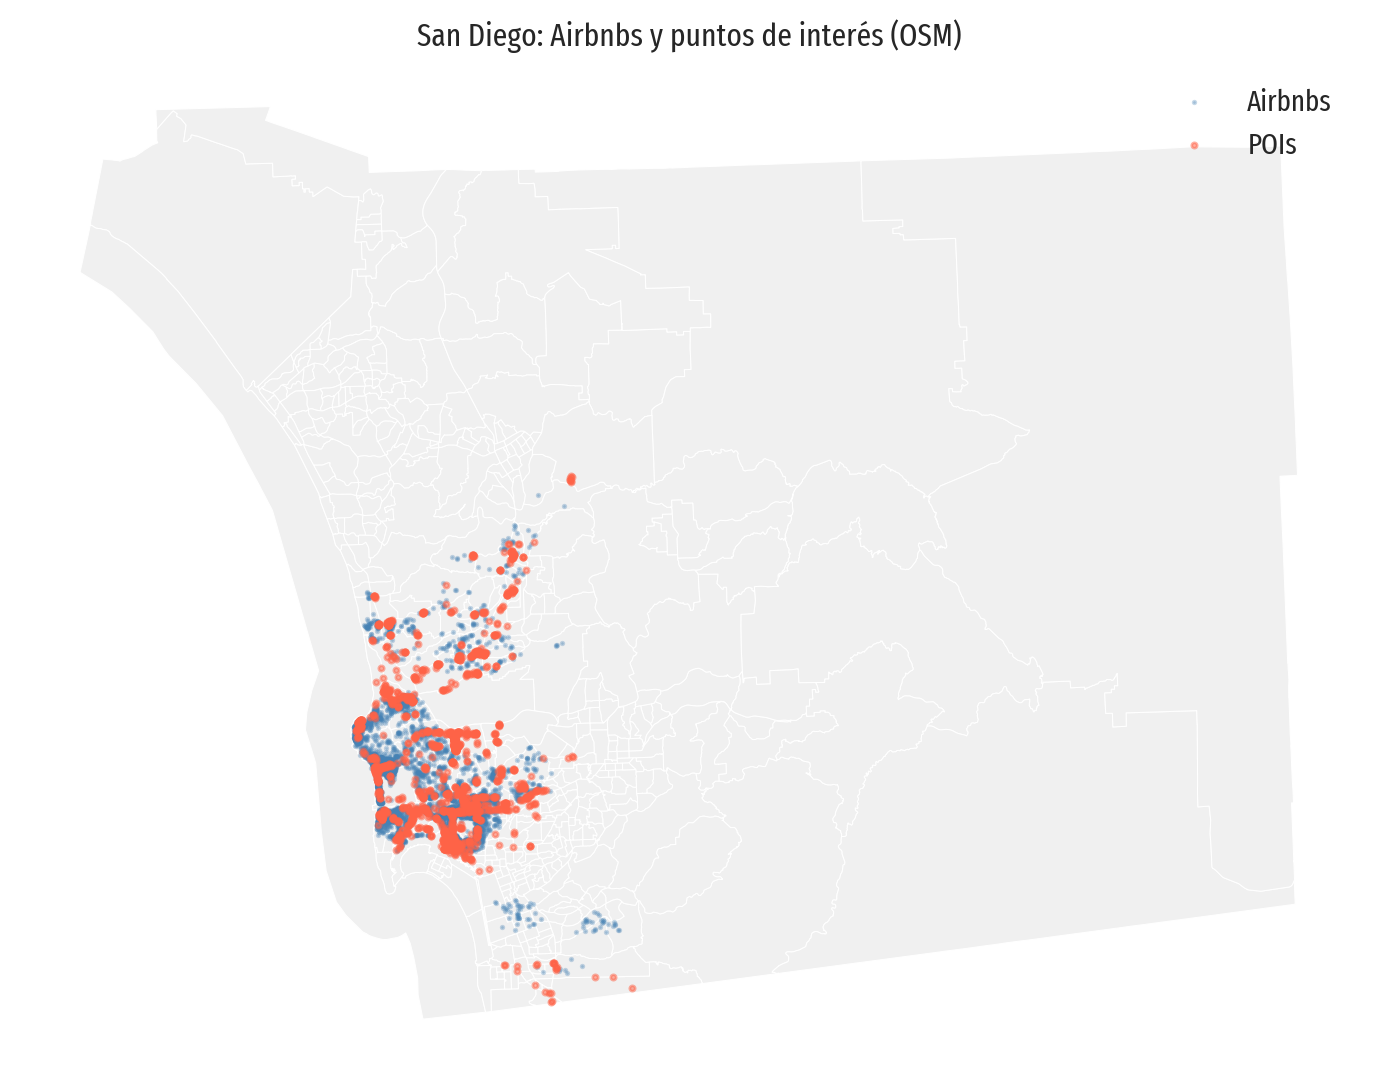

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
#tracts
tracts.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.4)
#airbnbs 
db.plot(ax=ax, markersize=1, alpha=0.3, color="steelblue", label="Airbnbs")
#pois
pois.plot(ax=ax, markersize=4, alpha=0.5, color="tomato", label="POIs")
ax.legend(frameon=False)
ax.set_axis_off()
ax.set_title("San Diego: Airbnbs y puntos de interés (OSM)", fontsize=12)
plt.show()

---
# Parte 1: Map Matching

La idea es usar la **ubicación como llave de cruce** entre datasets independientes. Equivale a un `JOIN` en SQL, pero en vez de una columna de ID, usamos relaciones geométricas: ¿el punto está dentro del buffer? ¿En qué polígono cae?

## 2. Contar POIs cercanos: buffer + `sjoin`

**Pregunta:** ¿cuántos restaurantes, bares y cafés hay a 500 metros de cada Airbnb?

Estar rodeado de gastronomía es un proxy de centralidad urbana. No predice el precio de forma directa, sino porque ambos son síntomas de barrios con cierto perfil.

**Pasos:**
1. Buffer de 500 m alrededor de cada propiedad.
2. `sjoin` para saber qué POIs caen dentro de cada buffer.
3. Agrupar por propiedad y contar.

In [5]:
# Paso 1: buffer
db["buffer_500m"] = db.geometry.buffer(500)

# Area promedio
print(f"Área promedio del buffer: {db['buffer_500m'].area.mean():,.0f} m²")


Área promedio del buffer: 784,137 m²


In [6]:
db.head()

,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry,buffer_500m
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (269312.639 -580195.744),"POLYGON ((269812.639 -580195.744, 269810.232 -..."
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (257694.376 -577191.922),"POLYGON ((258194.376 -577191.922, 258191.968 -..."
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (268236.085 -580308.812),"POLYGON ((268736.085 -580308.812, 268733.677 -..."
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (266568.078 -560652.692),"POLYGON ((267068.078 -560652.692, 267065.671 -..."
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (261003.776 -581770.057),"POLYGON ((261503.776 -581770.057, 261501.368 -..."


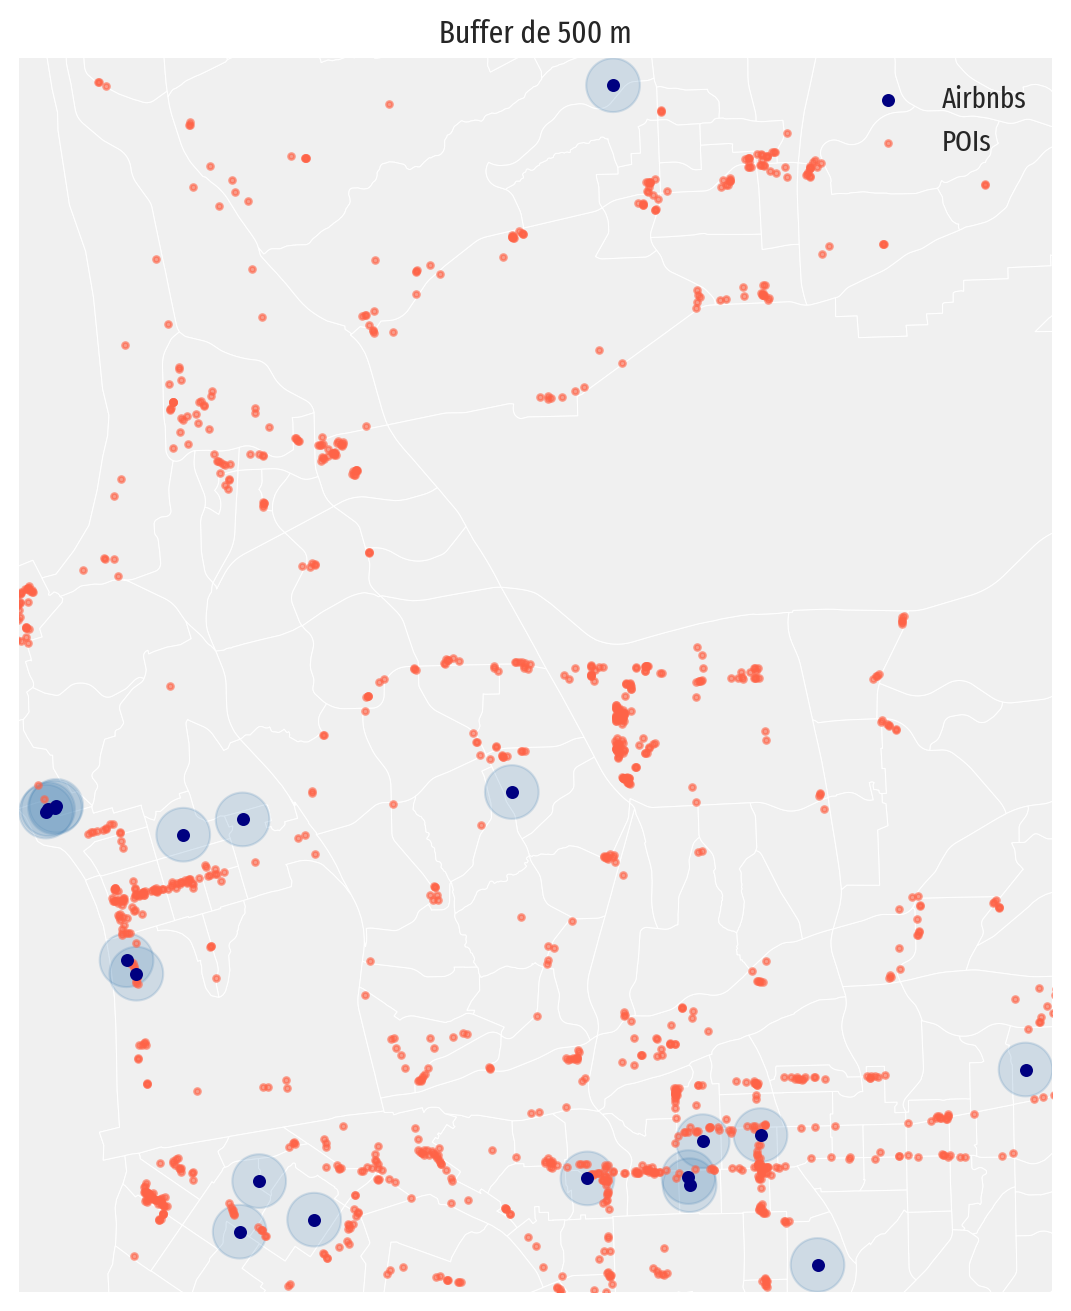

In [7]:
# Zoom a una zona para ver los buffers en el mapa
# Usamos el centro de San Diego (downtown)
zona = db.iloc[:20].copy()

fig, ax = plt.subplots(figsize=(9, 7))
#grafico tracts 
tracts.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.4)
#fijo la geometría del buffer para graficar
zona.set_geometry("buffer_500m").plot(ax=ax, alpha=0.2, color="steelblue", edgecolor="steelblue", linewidth=0.8)
#grafico zona con geometría original para mostrar los puntos
zona.plot(ax=ax, markersize=15, color="navy", zorder=5, label="Airbnbs")
#grafico POIs
pois.plot(ax=ax, markersize=5, color="tomato", alpha=0.6, label="POIs")

# Zoom al área de los puntos
minx, miny, maxx, maxy = zona.set_geometry("buffer_500m").total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.legend(frameon=False)
ax.set_axis_off()
ax.set_title("Buffer de 500 m")
plt.tight_layout()
plt.show()

In [8]:
# Paso 2: sjoin. ¿Qué POIs caen dentro de cada buffer?
db_buf = db.set_geometry("buffer_500m")
joined = gpd.sjoin(pois, db_buf, how="inner", predicate="within")
print(f"Filas del join: {len(joined):,}  (pares POI–Airbnb)")

Filas del join: 88,008  (pares POI–Airbnb)


In [9]:
joined.head()

,amenity,name,geometry_left,index_right,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry_right
0,restaurant,Leucadia Pizzeria & Italian Restaurant,POINT (260043.826 -568463.827),656,2,1.0,1.0,1.0,University City,1,16.553280,0,60.0,4.094345,2043418,1,0,0,0,0,0,1,0,POINT (260247.143 -568110.346)
0,restaurant,Leucadia Pizzeria & Italian Restaurant,POINT (260043.826 -568463.827),991,2,1.5,1.0,1.0,University City,0,16.084238,0,150.0,5.010635,3113120,1,0,0,0,0,0,1,0,POINT (260371.658 -568570.594)
0,restaurant,Leucadia Pizzeria & Italian Restaurant,POINT (260043.826 -568463.827),1516,2,1.0,1.0,1.0,University City,1,16.421665,0,60.0,4.094345,4625302,1,0,0,0,0,0,1,0,POINT (260236.760 -568262.375)
0,restaurant,Leucadia Pizzeria & Italian Restaurant,POINT (260043.826 -568463.827),1529,5,2.0,2.0,2.0,University City,1,16.411950,0,150.0,5.010635,4679707,1,0,0,0,0,1,0,0,POINT (260212.581 -568285.549)
0,restaurant,Leucadia Pizzeria & Italian Restaurant,POINT (260043.826 -568463.827),1588,2,1.0,1.0,2.0,University City,1,16.527811,0,40.0,3.688879,4855831,1,0,0,0,0,0,1,0,POINT (260010.411 -568260.248)


### `index_right` en `gpd.sjoin()`

Al hacer un spatial join con GeoPandas:

    gpd.sjoin(izquierdo, derecho, ...)

el resultado conserva la geometría y el índice del GeoDataFrame izquierdo.
El índice del GeoDataFrame derecho no puede quedar como índice de la tabla
resultante (ya está ocupado), así que GeoPandas lo agrega como una columna
llamada `index_right`.


Si invirtieras el orden de los argumentos, la columna se llamaría igual
pero ahora identificaría al que antes era el izquierdo.

In [10]:
# Paso 3: contar POIs por Airbnb
n_pois = joined.groupby("index_right").size().rename("n_pois_500m")
db = db.join(n_pois)
db.head()

,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry,buffer_500m,n_pois_500m
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (269312.639 -580195.744),"POLYGON ((269812.639 -580195.744, 269810.232 -...",16.0
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (257694.376 -577191.922),"POLYGON ((258194.376 -577191.922, 258191.968 -...",13.0
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (268236.085 -580308.812),"POLYGON ((268736.085 -580308.812, 268733.677 -...",14.0
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (266568.078 -560652.692),"POLYGON ((267068.078 -560652.692, 267065.671 -...",NaN
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (261003.776 -581770.057),"POLYGON ((261503.776 -581770.057, 261501.368 -...",NaN


In [11]:
db["n_pois_500m"] = db["n_pois_500m"].fillna(0).astype(int)



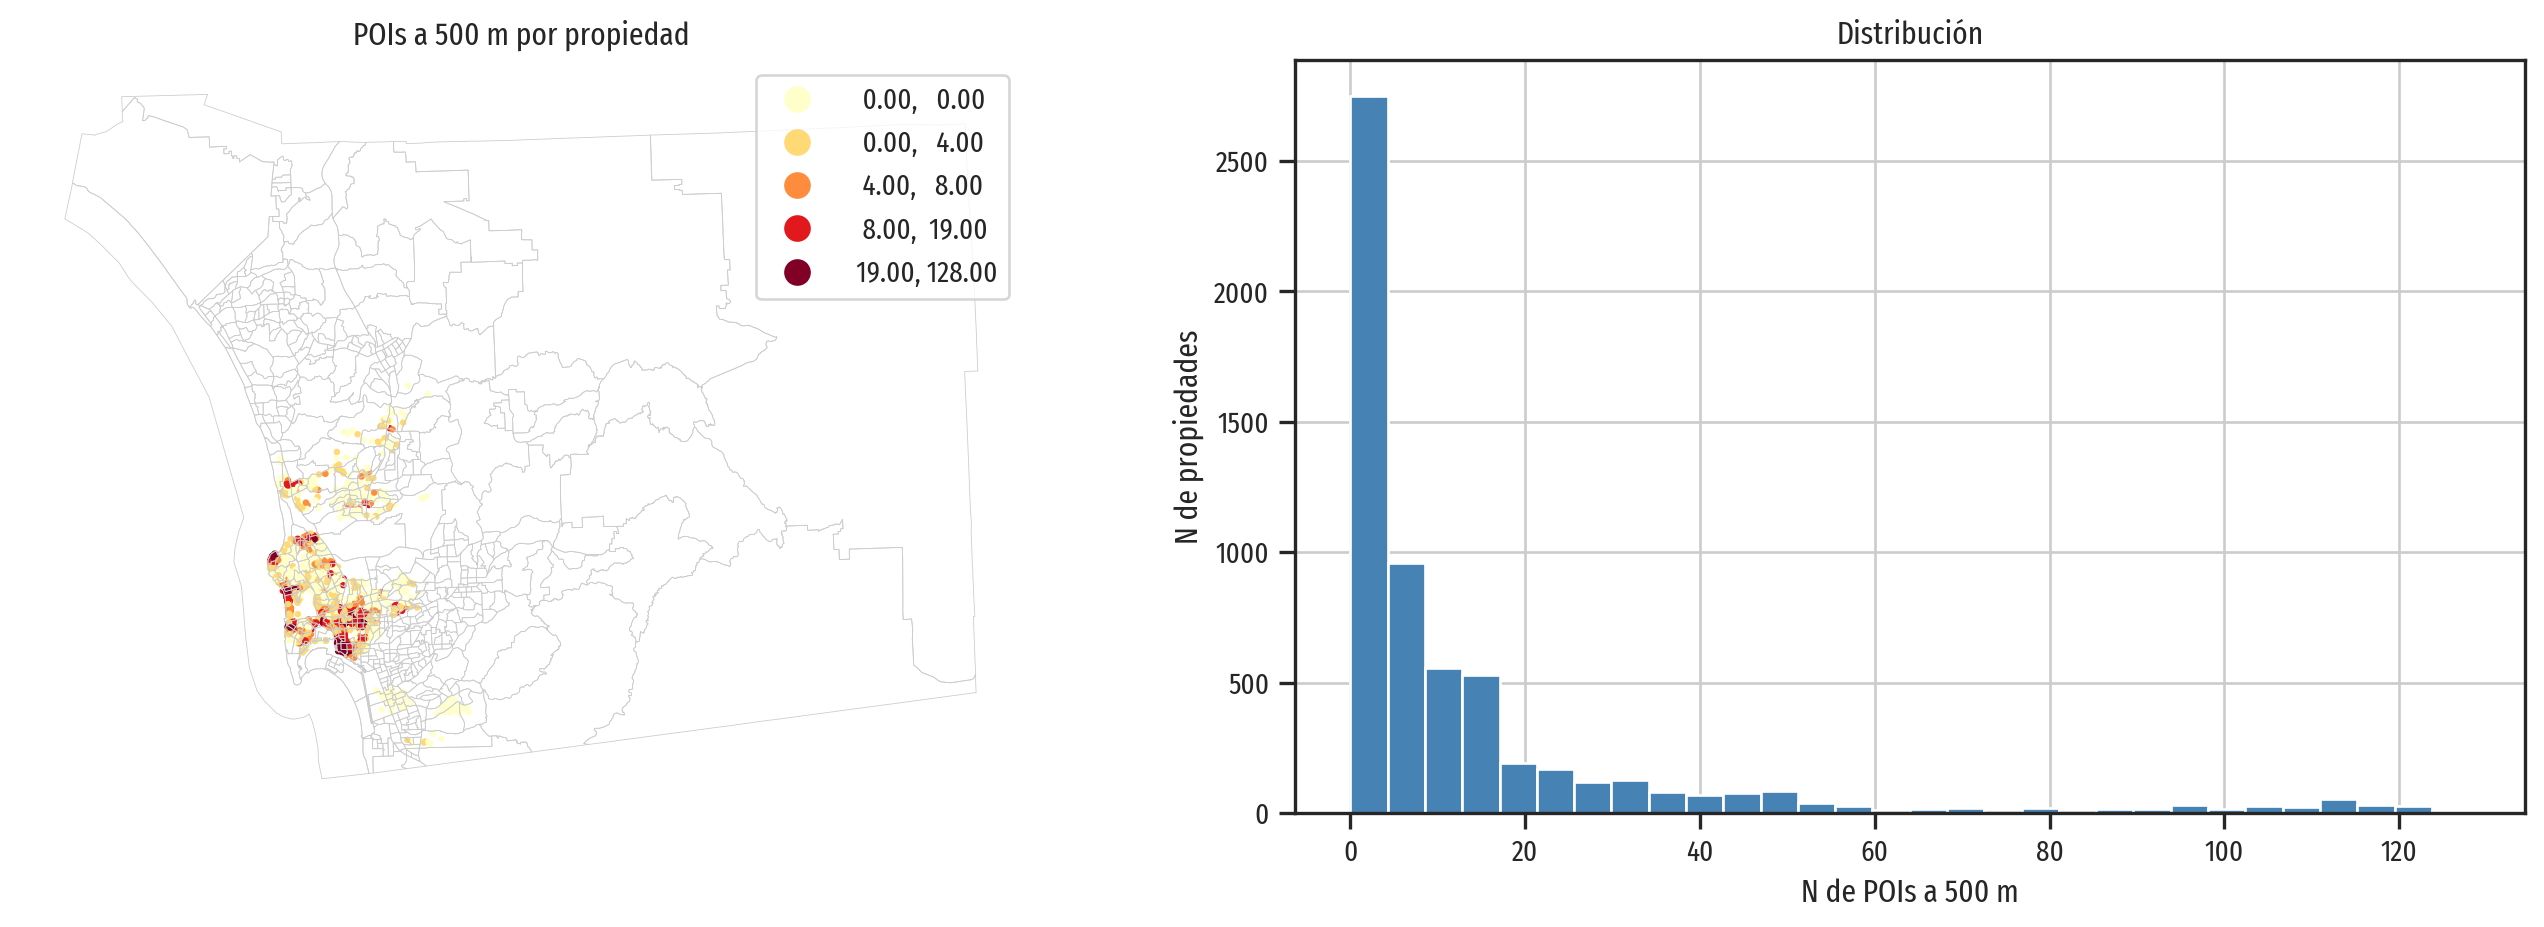

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

db.plot(column="n_pois_500m", scheme="quantiles", k=5,
        cmap="YlOrRd", markersize=2, legend=True, ax=axes[0])
tracts.plot(ax=axes[0], facecolor="none", edgecolor="#cccccc", linewidth=0.3)
axes[0].set_axis_off()
axes[0].set_title("POIs a 500 m por propiedad")

db["n_pois_500m"].hist(bins=30, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_xlabel("N de POIs a 500 m")
axes[1].set_ylabel("N de propiedades")
axes[1].set_title("Distribución")

plt.tight_layout()
plt.show()

La concentración de POIs no es uniforme: la costa y el centro tienen densidades mucho más altas. 

**Nota**: las propiedades en el borde del área de estudio tienen buffers que se «salen» del mapa, así que probablemente *subestiman* los POIs reales. Si la precisión importa, habría que descargar un área más amplia de OSM.

## 3. Elevación desde un raster: point sampling

**Pregunta:** ¿a qué elevación está cada propiedad?

El archivo `nasadem_sd.tif` es un **modelo digital de elevación** (DEM) del satélite NASADEM, con resolución de ~30 m. Cada píxel almacena la altura en metros sobre el nivel del mar.

**Operación:** leer el valor del raster en las coordenadas exactas de cada punto. En `rasterstats` esto se llama `point_query`.

In [13]:
dem = rioxarray.open_rasterio(f"{RUTA}/nasadem/nasadem_sd.tif", masked=True)
print(f"CRS del DEM : {dem.rio.crs}")
print(f"Resolución  : {dem.rio.resolution()} grados")
print(f"Shape       : {dem.shape}  (bandas × filas × columnas)")

CRS del DEM : EPSG:4326
Resolución  : (0.0002777777777777778, -0.0002777777777777778) grados
Shape       : (1, 3515, 5510)  (bandas × filas × columnas)


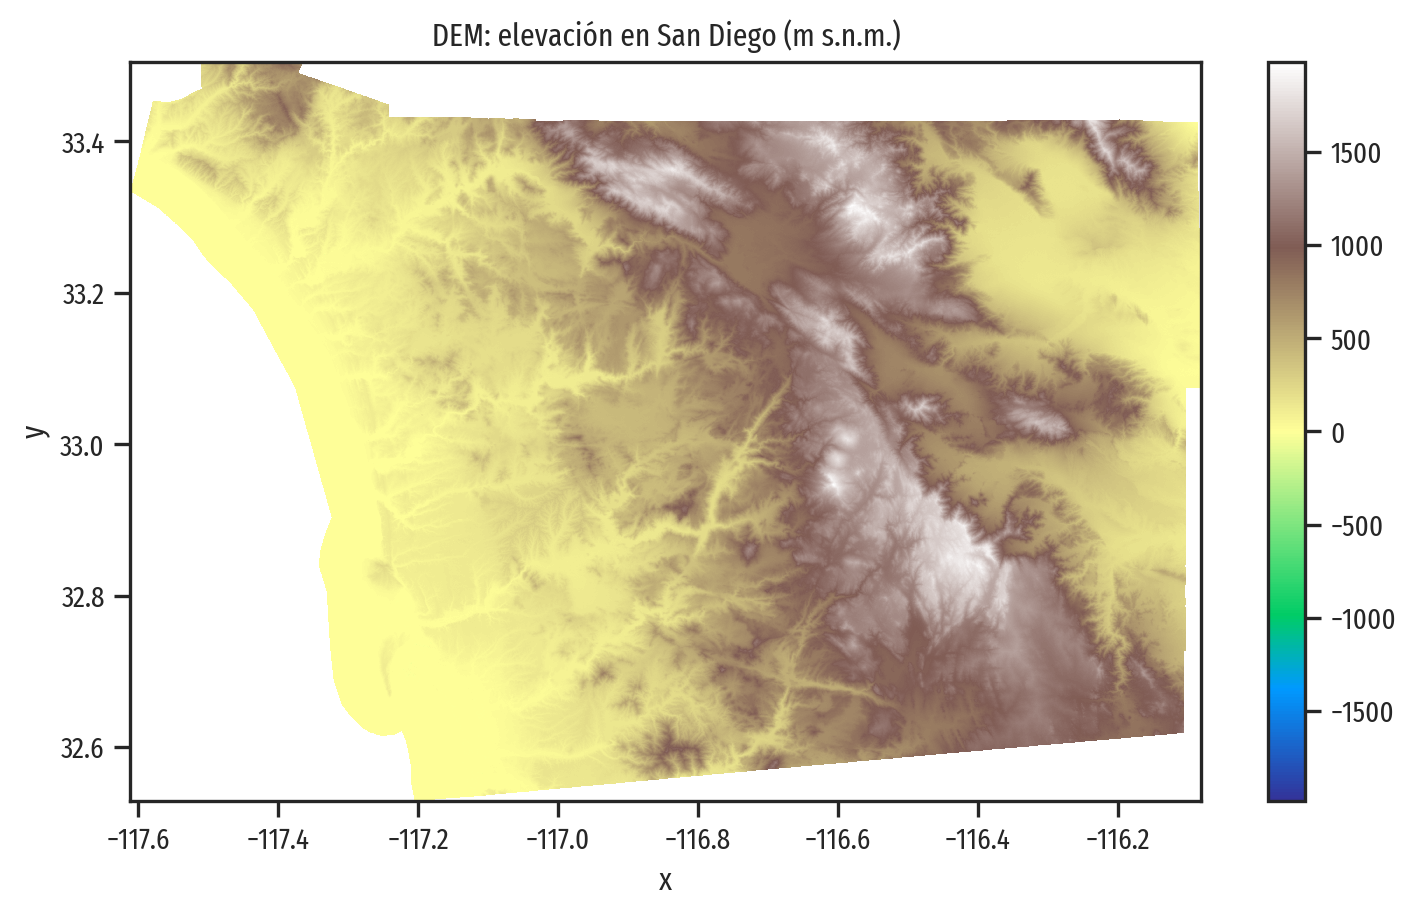

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
# squeeze: elimina la dimensión de banda (1, filas, cols) → (filas, cols)
dem.squeeze().plot(ax=ax, cmap="terrain", add_colorbar=True)
ax.set_title("DEM: elevación en San Diego (m s.n.m.)")
plt.show()

In [15]:
#no estan en el mismo CRS, por eso hay que reproyectar los puntos al CRS del DEM
print(db.crs)
print(dem.rio.crs)

EPSG:3311
EPSG:4326


In [16]:
db.head()

,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry,buffer_500m,n_pois_500m
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (269312.639 -580195.744),"POLYGON ((269812.639 -580195.744, 269810.232 -...",16
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (257694.376 -577191.922),"POLYGON ((258194.376 -577191.922, 258191.968 -...",13
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (268236.085 -580308.812),"POLYGON ((268736.085 -580308.812, 268733.677 -...",14
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (266568.078 -560652.692),"POLYGON ((267068.078 -560652.692, 267065.671 -...",0
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (261003.776 -581770.057),"POLYGON ((261503.776 -581770.057, 261501.368 -...",0


In [17]:
# Point sampling: extraer el valor del raster en cada Airbnb
# rasterstats necesita los puntos en el mismo CRS que el raster (WGS84)
db_wgs = db.set_geometry("geometry").to_crs(dem.rio.crs)

# point_query: para cada punto extrae el valor del raster en esa coordenada
db["elevacion_m"] = rasterstats.point_query(
    db_wgs.geometry,
    f"{RUTA}/nasadem/nasadem_sd.tif",
    interpolate="nearest"  # valor del píxel más cercano a cada punto, sin interpolar
)

db.head()


,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry,buffer_500m,n_pois_500m,elevacion_m
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (269312.639 -580195.744),"POLYGON ((269812.639 -580195.744, 269810.232 -...",16,112
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (257694.376 -577191.922),"POLYGON ((258194.376 -577191.922, 258191.968 -...",13,3
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (268236.085 -580308.812),"POLYGON ((268736.085 -580308.812, 268733.677 -...",14,99
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (266568.078 -560652.692),"POLYGON ((267068.078 -560652.692, 267065.671 -...",0,114
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (261003.776 -581770.057),"POLYGON ((261503.776 -581770.057, 261501.368 -...",0,30


In [18]:
print(f"Elevación media : {db['elevacion_m'].mean():.1f} m")
print(f"Elevación máxima: {db['elevacion_m'].max():.1f} m")
print(f"Valores nulos   : {db['elevacion_m'].isna().sum()}")

Elevación media : 51.0 m
Elevación máxima: 318.0 m
Valores nulos   : 0


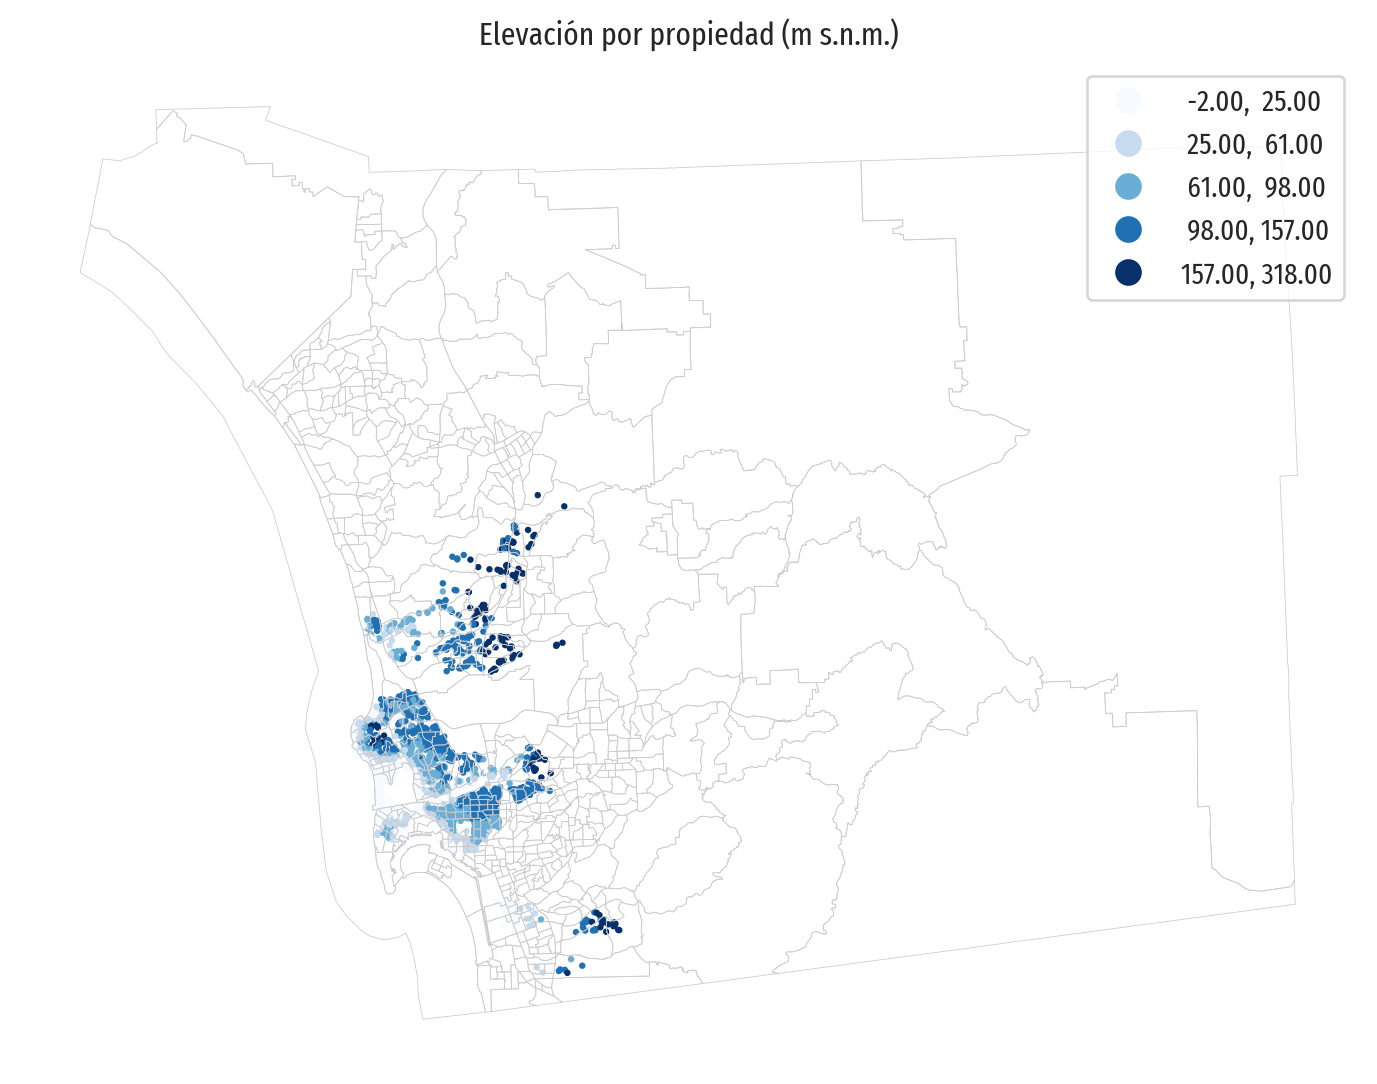

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
db.set_geometry("geometry").plot(
    column="elevacion_m", scheme="fisherjenks", k=5,
    cmap="Blues", markersize=2, legend=True, ax=ax)

tracts.plot(ax=ax, facecolor="none", edgecolor="#cccccc", linewidth=0.3)
ax.set_axis_off()
ax.set_title("Elevación por propiedad (m s.n.m.)")
plt.show()

## 4. Heredar atributos de polígonos: punto en polígono

**Pregunta:** ¿cuáles son las características socioeconómicas del census tract donde está cada propiedad?

**Operación:** `sjoin` con predicado `within`. Cada punto hereda los atributos del polígono que lo contiene.



In [20]:
tracts[["GEOID", "median_hh_income", "pct_bachelor", "total_pop"]].head(3)

,GEOID,median_hh_income,pct_bachelor,total_pop
0,06073018300,62500.0,0.000000,2590.0
1,06073018601,88165.0,0.004663,5147.0
2,06073017601,110804.0,0.006077,5595.0


In [21]:
# Restauramos la geometría de punto
db = db.set_geometry("geometry")

vars_tract = ["GEOID", "median_hh_income", "pct_bachelor", "total_pop", "area_sqm", "geometry"]

db = gpd.sjoin(
    db,
    tracts[vars_tract],
    how="left",
    predicate="within"
).drop(columns="index_right")

# Densidad poblacional del tract
db["densidad_pop"] = db["total_pop"] / (db["area_sqm"] / 1e6)

print(f"Propiedades sin tract asignado: {db['GEOID'].isna().sum()}")

Propiedades sin tract asignado: 0


In [22]:
db.head()

,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry,buffer_500m,n_pois_500m,elevacion_m,GEOID,median_hh_income,pct_bachelor,total_pop,area_sqm,densidad_pop
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (269312.639 -580195.744),"POLYGON ((269812.639 -580195.744, 269810.232 -...",16,112,06073001300,55859.0,0.001639,6102.0,0.791929,7.705241e+09
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (257694.376 -577191.922),"POLYGON ((258194.376 -577191.922, 258191.968 -...",13,3,06073007600,66212.0,0.004500,4667.0,19.205454,2.430039e+08
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (268236.085 -580308.812),"POLYGON ((268736.085 -580308.812, 268733.677 -...",14,99,06073000900,51359.0,0.004926,5481.0,0.621678,8.816458e+09
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (266568.078 -560652.692),"POLYGON ((267068.078 -560652.692, 267065.671 -...",0,114,06073008346,150405.0,0.007371,5020.0,11.734465,4.277997e+08
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (261003.776 -581770.057),"POLYGON ((261503.776 -581770.057, 261501.368 -...",0,30,06073006900,103782.0,0.000000,5721.0,1.820436,3.142654e+09


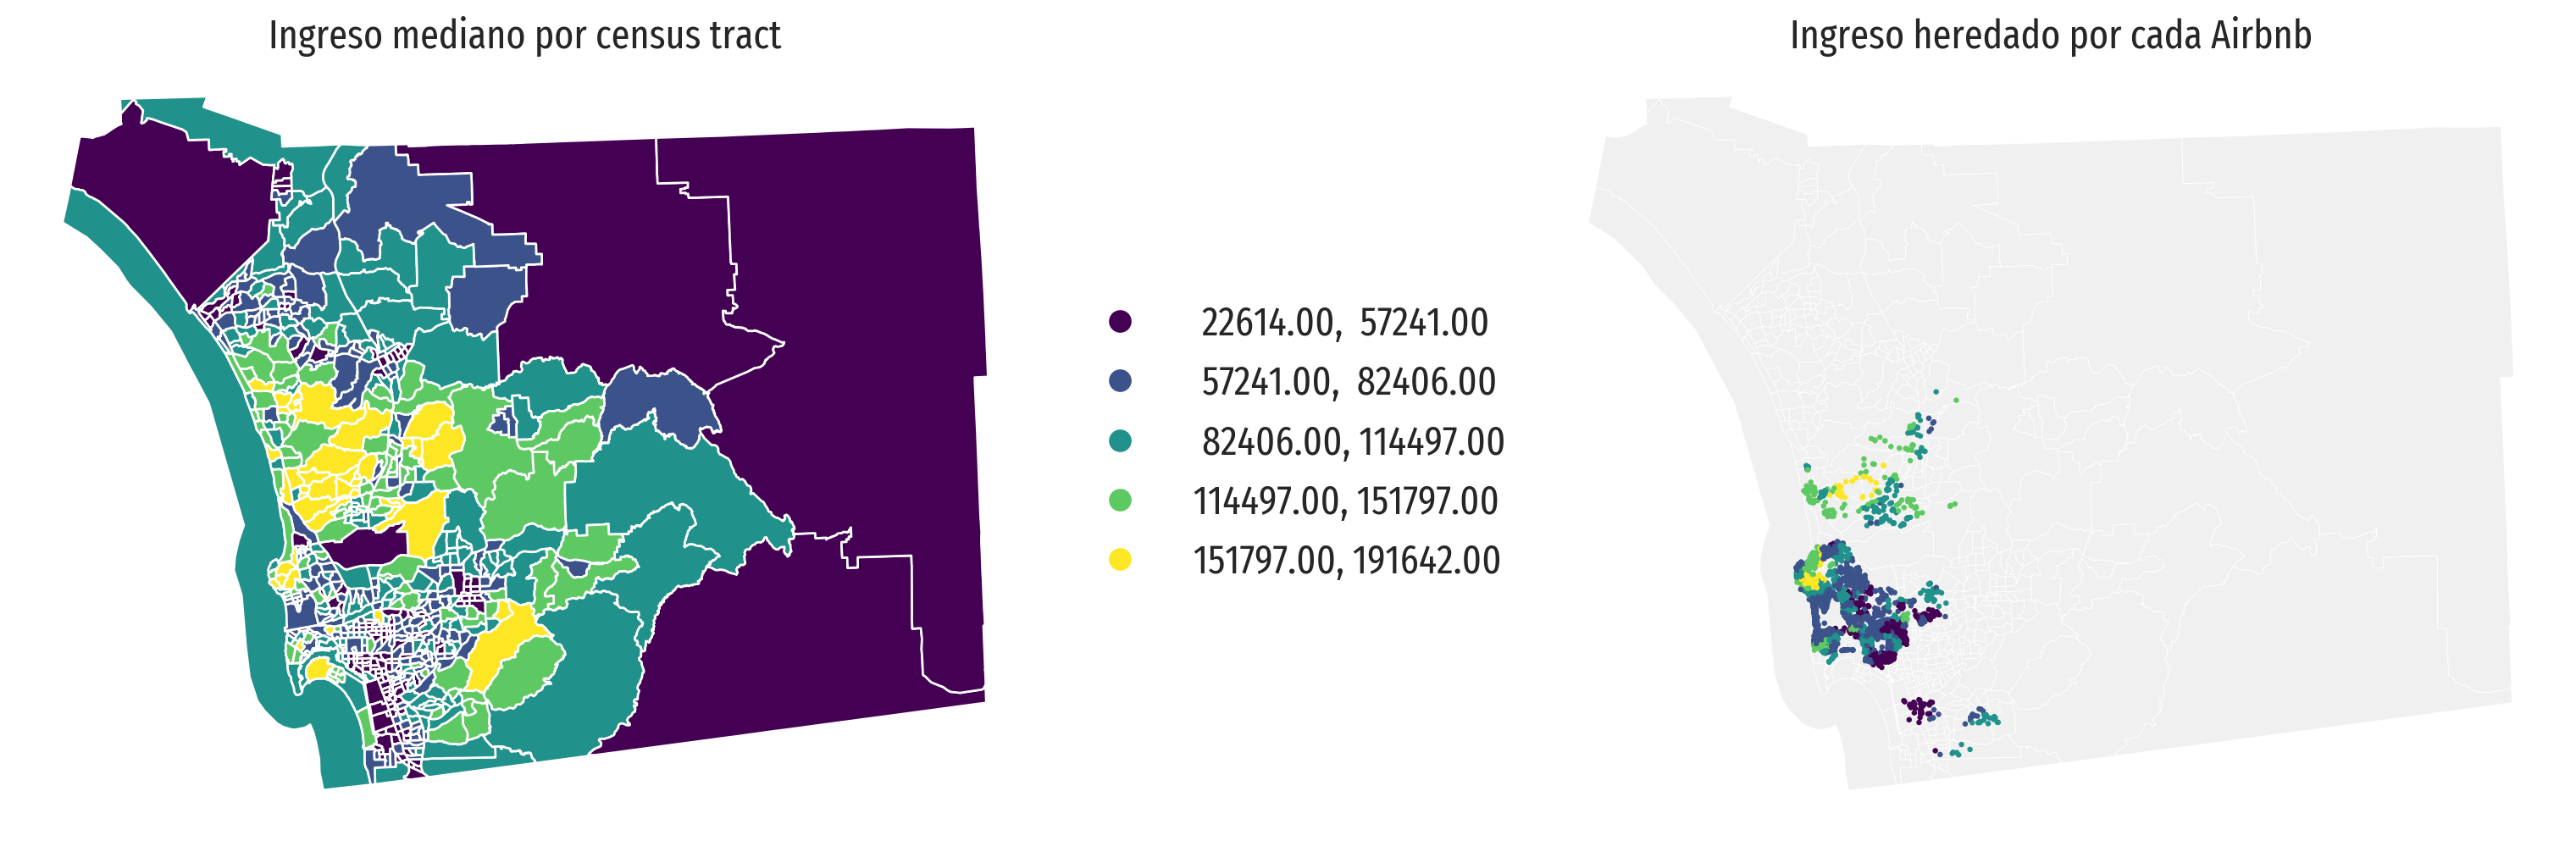

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tracts.plot(column="median_hh_income", scheme="fisherjenks", k=5,
            cmap="viridis", legend=False, ax=axes[0])
axes[0].set_axis_off()
axes[0].set_title("Ingreso mediano por census tract", fontsize=18)

tracts.plot(ax=axes[1], color="#f0f0f0", edgecolor="white", linewidth=0.3)
db.plot(column="median_hh_income", scheme="fisherjenks", k=5,
        cmap="viridis", markersize=2, legend=True, ax=axes[1],
        legend_kwds={"frameon": False, "fontsize": 18})
axes[1].set_axis_off()
axes[1].set_title("Ingreso heredado por cada Airbnb", fontsize=18)

# Mover la leyenda del panel derecho al centro entre ambos paneles
leg = axes[1].get_legend()
leg.set_bbox_to_anchor((0, 0.5))
leg.set_loc("right")
plt.savefig("mapa_ingreso.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

---
# Parte 2: ¿Mejora la regresión?

En la clase 08 construimos un OLS del log-precio con variables físicas de la propiedad. La pregunta ahora es: **¿agregar las features de map matching mejora ese modelo? ¿Y en qué punto hay que pasar a SAR o SEM?**

Comparamos cuatro especificaciones:

| Modelo | Variables |
|---|---|
| OLS base (clase 08) | atributos físicos de la propiedad |
| OLS + map matching | base + POIs, elevación, ingreso del tract, educación |
| SAR + map matching | anterior + lag espacial de Y en el modelo |
| SEM + map matching | anterior + autocorrelación en el error |

In [24]:
vars_base     = [
    "accommodates", "bathrooms", "bedrooms", "beds", "d2balboa",
    "rt_Private_room", "rt_Shared_room",
    "pg_Condominium", "pg_House", "pg_Other", "pg_Townhouse",
]
vars_matching = ["n_pois_500m", "elevacion_m", "median_hh_income", "pct_bachelor"]

In [25]:
# Subconjunto limpio (sin NaN en ninguna variable)
mask  = db[vars_base + vars_matching + ["log_price"]].notna().all(axis=1)
db_c  = db[mask].copy()           # GeoDataFrame (conserva geometría)
y_c   = db_c[["log_price"]].values

print(f"Propiedades usadas: {len(db_c):,}  (de {len(db):,} originales)")

Propiedades usadas: 6,110  (de 6,110 originales)


In [26]:
# Matriz de pesos KNN k=8 — usamos el GeoDataFrame para conservar geometría
wknn = weights.KNN.from_dataframe(db_c, k=8, silence_warnings=True)
wknn.transform = "r"

X_base = db_c[vars_base].values
X_match = db_c[vars_base + vars_matching].values

# OLS base (clase 08)
m_base = spreg.OLS(
    y_c, X_base, w=wknn, spat_diag=True, moran=True,
    name_y="log_price", name_x=vars_base
)

# SAR (lag espacial en Y)
m_sar_base = spreg.ML_Lag(
    y_c, X_base, wknn,
    name_y="log_price", name_x=vars_base
)

# SEM base (clase 08)
m_sem_base = spreg.ML_Error(
    y_c, X_base, wknn,
    name_y="log_price", name_x=vars_base
)

# OLS + map matching (con diagnóstico espacial)
m_ols = spreg.OLS(
    y_c, X_match, w=wknn, spat_diag=True, moran=True,
    name_y="log_price", name_x=vars_base + vars_matching
)

# SAR (lag espacial en Y)
m_sar = spreg.ML_Lag(
    y_c, X_match, wknn,
    name_y="log_price", name_x=vars_base + vars_matching
)

# SEM (autocorrelación en el error)
m_sem = spreg.ML_Error(
    y_c, X_match, wknn,
    name_y="log_price", name_x=vars_base + vars_matching
)

print(f"{'Modelo':38s}  {'R²':>7s}  {'AIC':>9s}")
print("-" * 60)
print(f"{'OLS base (clase 08)':38s}  {m_base.r2:7.3f}  {m_base.aic:9.1f}")
print(f"{'SAR base (rho={:.3f})'.format(float(m_sar.rho)):38s}  {m_sar_base.pr2:7.3f}  {m_sar_base.aic:9.1f}")
print(f"{'SEM base (lam={:.3f})'.format(float(m_sem.lam)):38s}  {m_sem_base.pr2:7.3f}  {m_sem_base.aic:9.1f}")
print(f"{'OLS + map matching':38s}  {m_ols.r2:7.3f}  {m_ols.aic:9.1f}")
print(f"{'SAR + map matching  (rho={:.3f})'.format(float(m_sar.rho)):38s}  {m_sar.pr2:7.3f}  {m_sar.aic:9.1f}")
print(f"{'SEM + map matching  (lam={:.3f})'.format(float(m_sem.lam)):38s}  {m_sem.pr2:7.3f}  {m_sem.aic:9.1f}")

ML_Lag
ML_Error
ML_Lag
ML_Error
Modelo                                       R²        AIC
------------------------------------------------------------
OLS base (clase 08)                       0.669     7998.9
SAR base (rho=0.234)                      0.704     7365.5
SEM base (lam=0.309)                      0.666     7480.2
OLS + map matching                        0.698     7438.0
SAR + map matching  (rho=0.234)           0.714     7137.2
SEM + map matching  (lam=0.309)           0.698     7265.2


In [27]:
print(f"{'Modelo':38s}  {'R²':>7s}  {'AIC':>9s}")
print("-" * 60)
print(f"{'OLS base (clase 08)':38s}  {m_base.r2:7.3f}  {m_base.aic:9.1f}")
print(f"{'SAR base (rho={:.3f})'.format(float(m_sar.rho)):38s}  {m_sar_base.pr2:7.3f}  {m_sar_base.aic:9.1f}")
print(f"{'SEM base (lam={:.3f})'.format(float(m_sem.lam)):38s}  {m_sem_base.pr2:7.3f}  {m_sem_base.aic:9.1f}")
print(f"{'OLS + map matching':38s}  {m_ols.r2:7.3f}  {m_ols.aic:9.1f}")
print(f"{'SAR + map matching  (rho={:.3f})'.format(float(m_sar.rho)):38s}  {m_sar.pr2:7.3f}  {m_sar.aic:9.1f}")
print(f"{'SEM + map matching  (lam={:.3f})'.format(float(m_sem.lam)):38s}  {m_sem.pr2:7.3f}  {m_sem.aic:9.1f}")

Modelo                                       R²        AIC
------------------------------------------------------------
OLS base (clase 08)                       0.669     7998.9
SAR base (rho=0.234)                      0.704     7365.5
SEM base (lam=0.309)                      0.666     7480.2
OLS + map matching                        0.698     7438.0
SAR + map matching  (rho=0.234)           0.714     7137.2
SEM + map matching  (lam=0.309)           0.698     7265.2


In [28]:
# Diagnóstico espacial sobre residuos del OLS + map matching


In [29]:
print("Diagnóstico espacial (OLS):")
print(f"  Moran I residuos = {m_base.moran_res[0]:.3f}   p = {m_base.moran_res[2]:.4f}")
print(f"  LM-lag    p = {m_base.lm_lag[1]:.4f}   RLM-lag   p = {m_base.rlm_lag[1]:.4f}")
print(f"  LM-error  p = {m_base.lm_error[1]:.4f}   RLM-error p = {m_base.rlm_error[1]:.4f}")

Diagnóstico espacial (OLS):
  Moran I residuos = 0.160   p = 0.0000
  LM-lag    p = 0.0000   RLM-lag   p = 0.0000
  LM-error  p = 0.0000   RLM-error p = 0.0000


In [30]:
print("Diagnóstico espacial (OLS + map matching):")
print(f"  Moran I residuos = {m_ols.moran_res[0]:.3f}   p = {m_ols.moran_res[2]:.4f}")
print(f"  LM-lag    p = {m_ols.lm_lag[1]:.4f}   RLM-lag   p = {m_ols.rlm_lag[1]:.4f}")
print(f"  LM-error  p = {m_ols.lm_error[1]:.4f}   RLM-error p = {m_ols.rlm_error[1]:.4f}")


Diagnóstico espacial (OLS + map matching):
  Moran I residuos = 0.087   p = 0.0000
  LM-lag    p = 0.0000   RLM-lag   p = 0.0000
  LM-error  p = 0.0000   RLM-error p = 0.0004


## 5. Interpretación

Los seis modelos cuentan una historia progresiva:

| Modelo | R² | AIC | Qué agrega |
|---|---|---|---|
| OLS base (clase 08) | 0.669 | 7 999 | solo atributos físicos |
| SAR base | 0.704 | 7 365 | dependencia espacial en Y |
| SEM base | 0.666 | 7 480 | autocorrelación en el error |
| OLS + map matching | 0.698 | 7 438 | entorno territorial |
| **SAR + map matching** | **0.714** | **7 137** | dependencia espacial + entorno |
| SEM + map matching | 0.698 | 7 265 | error espacial + entorno |

**Las features de map matching ayudan**, pero de forma distinta según el modelo:

- En el **OLS** suman +3 pp de R² y bajan el AIC en 561 puntos — aportan información nueva que el modelo base no tenía.
- En el **SAR** suman solo +1 pp — el SAR ya capturaba gran parte del patrón espacial a través del lag de Y. Las features agregan algo, pero el modelo ya era bueno.
- En el **SEM** suman +3 pp — las features compensan parte de lo que el error espacial no podía explicar con variables.

**El SAR + map matching es el mejor modelo** (AIC más bajo). La combinación de features territoriales y dependencia espacial explícita es superior a cualquiera de los dos enfoques por separado.

**Lección central:** features espaciales y modelos espaciales son complementarios. Las features atacan la autocorrelación desde las variables explicativas; SAR y SEM la modelan directamente. El mejor resultado los combina.

> **Nota metodológica**
>
> **R² vs pseudo-R²:** el R² del OLS mide qué fracción de la varianza de $y$ explica el modelo. SAR y SEM se estiman por máxima verosimilitud, no por mínimos cuadrados, así que el R² clásico no aplica. `spreg` reporta un pseudo-R² = corr(y, ŷ)², que está en la misma escala (0 a 1) pero no es exactamente lo mismo. Por eso la comparación entre modelos es orientativa — para decidir formalmente entre modelos usar el **AIC**.
>
> **AIC (Criterio de Información de Akaike):** mide qué tan bien ajusta el modelo penalizando por el número de parámetros. Un AIC más bajo es mejor. La penalización evita que un modelo con más variables siempre "gane" solo por tener más parámetros. Regla práctica: una diferencia de AIC > 10 entre dos modelos es sustantiva.